# Visualizing how `fcwt2` works

`fcwt2` is a Rust-backed Python package for the fast Continuous Wavelet Transform (CWT). A CWT shows how much of each frequency is present at each moment in time. Unlike a single FFT, it keeps time localization; unlike a fixed-window spectrogram, wavelet resolution changes with frequency.

This notebook uses the package exactly as published on PyPI: build `Scales`, run `Fcwt.cwt_real`, reshape the scale-major output, and plot the complex coefficients.

## Setup

If you are running examples against unreleased local changes, install the checkout with `maturin develop` from the repository root. For released examples, installing `fcwt2` from PyPI is enough.


In [1]:
# Released package path:
# %pip install -q fcwt2 numpy matplotlib

# Local checkout path, run from the repository root or adjust the manifest path:
# %pip install -q maturin numpy matplotlib
# !maturin develop --manifest-path ../Cargo.toml


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

import fcwt2

plt.rcParams.update(
    {
        "figure.figsize": (12, 4),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fcwt2.Fcwt(), fcwt2.Scales.linear_frequencies(512, 8.0, 120.0, 8)

(Fcwt(bandwidth=2, normalize=True),
 Scales(sample_rate=512, values=[4.8301888, 5.5652175, 6.5641026, 8.0, 10.24, 14.222222, 23.272728, 64.0]))

## A signal with changing frequency

The signal below combines three behaviors that are easy to recognize in a time-frequency view:

- a chirp that sweeps upward from low to high frequency
- a short 75 Hz burst near the end
- a low-frequency tone that only exists in the first half

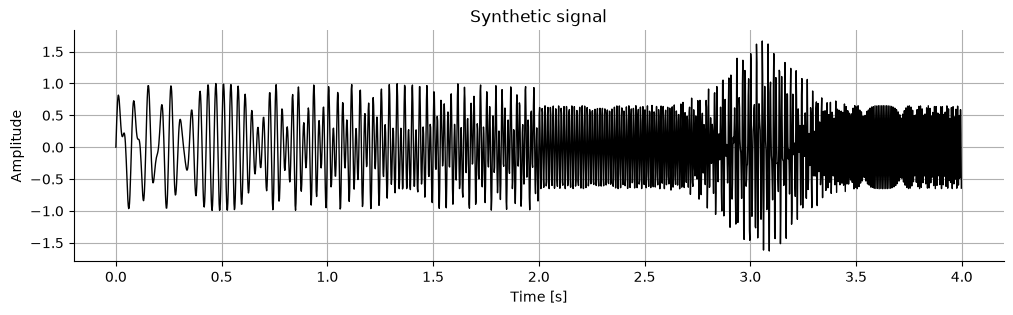

In [3]:
sample_rate = 512
duration = 4.0
n = int(sample_rate * duration)
t = np.arange(n) / sample_rate

# Linear chirp without SciPy: phase(t) = 2*pi*(f0*t + 0.5*k*t^2)
chirp_f0 = 12.0
chirp_f1 = 140.0
chirp_rate = (chirp_f1 - chirp_f0) / duration
chirp_phase = 2 * np.pi * (chirp_f0 * t + 0.5 * chirp_rate * t**2)
chirp = 0.65 * np.sin(chirp_phase)

low_tone = 0.35 * np.sin(2 * np.pi * 28.0 * t) * (t < 2.0)
burst_window = np.exp(-0.5 * ((t - 3.05) / 0.16) ** 2)
burst = 1.1 * burst_window * np.sin(2 * np.pi * 75.0 * t)
signal = (chirp + low_tone + burst).astype(np.float32)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, signal, lw=1.0, color="black")
ax.set(title="Synthetic signal", xlabel="Time [s]", ylabel="Amplitude")
plt.show()

## Run `fcwt2`

`fcwt2` returns one flat list of complex coefficients. The layout is scale-major:

```text
coefficients[scale_index * signal_length + sample_index]
```

The helper below reshapes that list to `[frequency, time]` and sorts frequencies from low to high so plotting is natural.

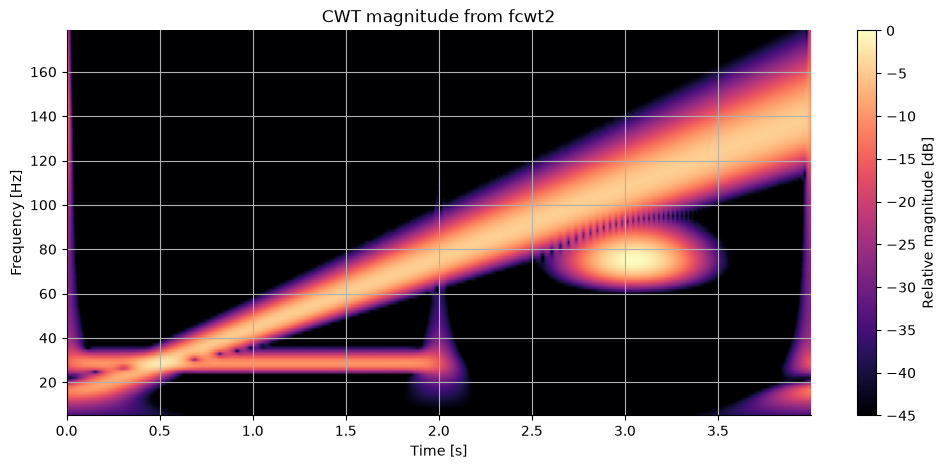

In [4]:
def cwt_matrix(signal, sample_rate, f0=5.0, f1=180.0, nscales=128, bandwidth=2.0):
    scales = fcwt2.Scales.linear_frequencies(sample_rate, f0, f1, nscales)
    transform = fcwt2.Fcwt.morlet(bandwidth)
    coeffs = transform.cwt_real(signal.astype(np.float32).tolist(), scales)
    coeffs = np.asarray(coeffs, dtype=np.complex64).reshape(len(scales), signal.size)
    freqs = np.asarray(scales.frequencies(), dtype=float)
    order = np.argsort(freqs)
    return freqs[order], coeffs[order]


def plot_cwt(ax, t, freqs, coeffs, title, vmin_db=-45):
    magnitude = np.abs(coeffs)
    db = 20 * np.log10(magnitude / (magnitude.max() + 1e-12) + 1e-12)
    image = ax.imshow(
        db,
        origin="lower",
        aspect="auto",
        extent=[t[0], t[-1], freqs[0], freqs[-1]],
        cmap="magma",
        vmin=vmin_db,
        vmax=0,
    )
    ax.set(title=title, xlabel="Time [s]", ylabel="Frequency [Hz]")
    return image


freqs, coeffs = cwt_matrix(signal, sample_rate)
fig, ax = plt.subplots(figsize=(12, 5))
image = plot_cwt(ax, t, freqs, coeffs, "CWT magnitude from fcwt2")
fig.colorbar(image, ax=ax, label="Relative magnitude [dB]")
plt.show()

The bright diagonal ridge is the chirp. The horizontal feature around 28 Hz disappears halfway through, and the compact feature around 75 Hz marks the burst.

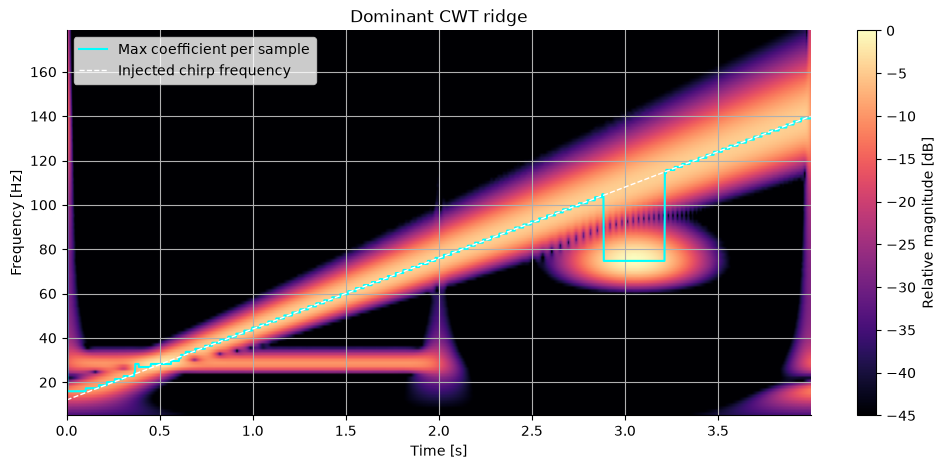

In [5]:
ridge_freq = freqs[np.argmax(np.abs(coeffs), axis=0)]
expected_chirp_freq = chirp_f0 + chirp_rate * t

fig, ax = plt.subplots(figsize=(12, 5))
image = plot_cwt(ax, t, freqs, coeffs, "Dominant CWT ridge")
ax.plot(t, ridge_freq, color="cyan", lw=1.5, label="Max coefficient per sample")
ax.plot(
    t,
    expected_chirp_freq,
    color="white",
    lw=1.0,
    ls="--",
    label="Injected chirp frequency",
)
ax.legend(loc="upper left")
fig.colorbar(image, ax=ax, label="Relative magnitude [dB]")
plt.show()

## Linear versus log-spaced scales

`Scales.linear_frequencies` gives nearly even frequency spacing. `Scales.log` places more detail in lower frequencies and wider spacing at higher frequencies. Both produce the same scale-major output layout.

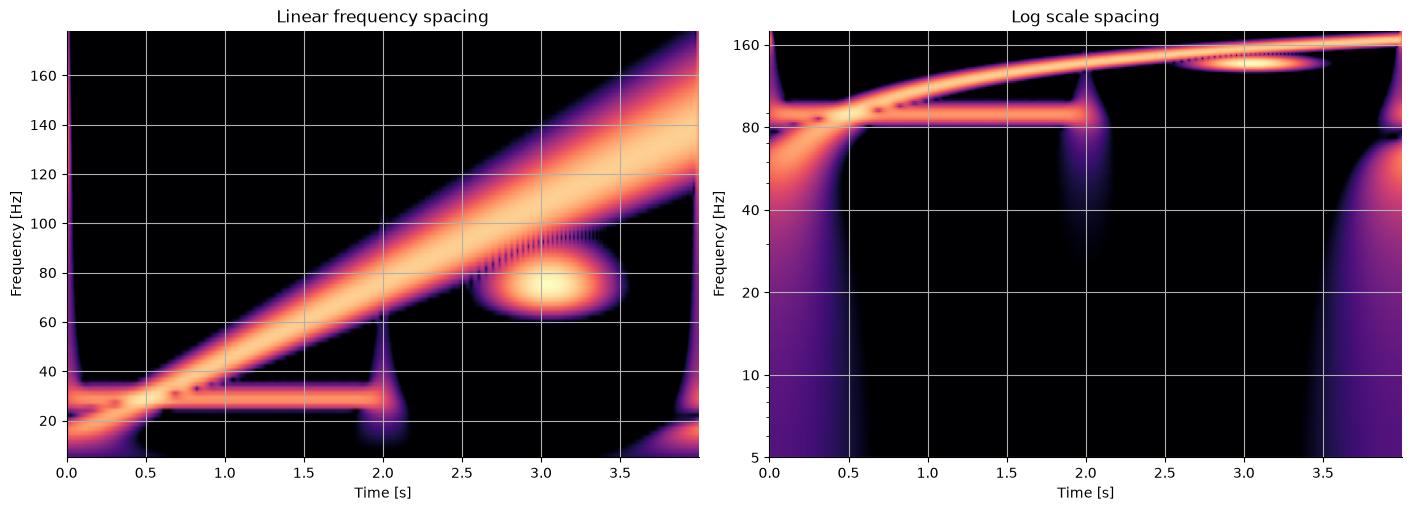

In [6]:
def cwt_with_scales(signal, scales, bandwidth=2.0):
    transform = fcwt2.Fcwt.morlet(bandwidth)
    coeffs = transform.cwt_real(signal.astype(np.float32).tolist(), scales)
    coeffs = np.asarray(coeffs, dtype=np.complex64).reshape(len(scales), signal.size)
    freqs = np.asarray(scales.frequencies(), dtype=float)
    order = np.argsort(freqs)
    return freqs[order], coeffs[order]


linear_scales = fcwt2.Scales.linear_frequencies(sample_rate, 5.0, 180.0, 96)
log_scales = fcwt2.Scales.log(sample_rate, 5.0, 180.0, 96)

linear_freqs, linear_coeffs = cwt_with_scales(signal, linear_scales)
log_freqs, log_coeffs = cwt_with_scales(signal, log_scales)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, constrained_layout=True)
plot_cwt(axes[0], t, linear_freqs, linear_coeffs, "Linear frequency spacing")
plot_cwt(axes[1], t, log_freqs, log_coeffs, "Log scale spacing")
axes[1].set_yscale("log")
axes[1].set_yticks([5, 10, 20, 40, 80, 160])
axes[1].get_yaxis().set_major_formatter(ScalarFormatter())
plt.show()

## Morlet bandwidth changes the tradeoff

A lower bandwidth is more localized in time. A higher bandwidth gives smoother, narrower frequency bands. The right choice depends on whether your signal has brief events, stable tones, or both.

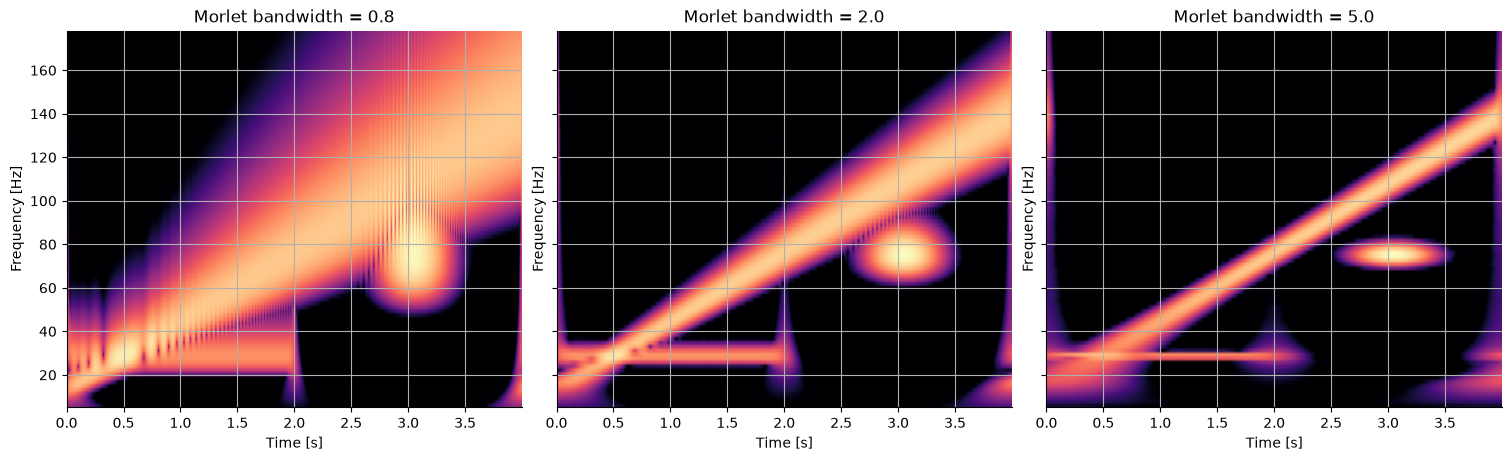

In [7]:
bandwidths = [0.8, 2.0, 5.0]
fig, axes = plt.subplots(
    1,
    len(bandwidths),
    figsize=(15, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, bandwidth in zip(axes, bandwidths):
    bw_freqs, bw_coeffs = cwt_matrix(
        signal, sample_rate, nscales=96, bandwidth=bandwidth
    )
    plot_cwt(ax, t, bw_freqs, bw_coeffs, f"Morlet bandwidth = {bandwidth}")

plt.show()

## The coefficients are complex

The magnitude is usually easiest to interpret visually, but the phase is also available. This is useful for phase locking, relative timing, and comparing channels.

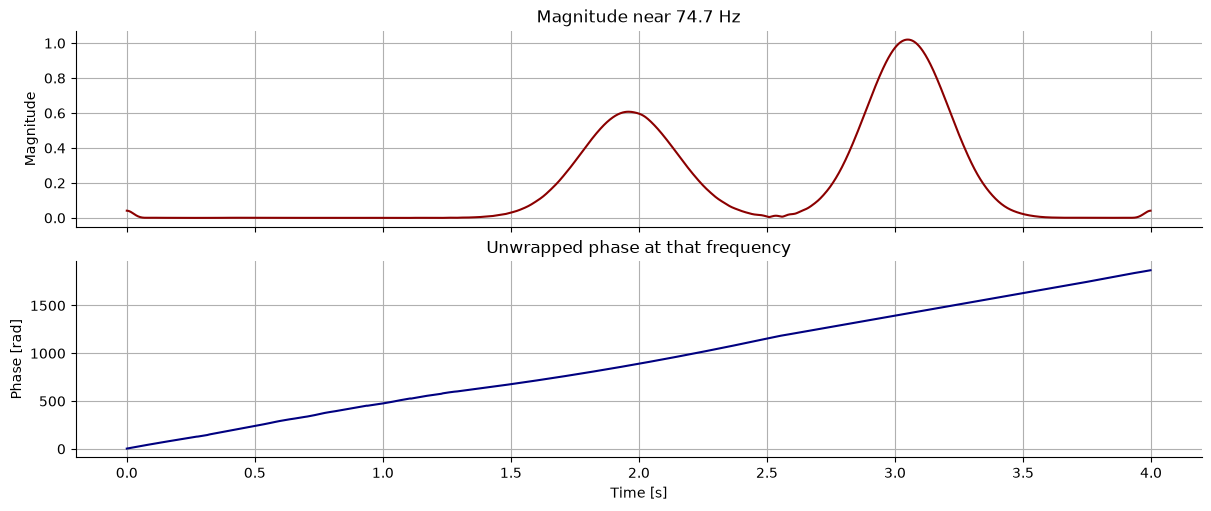

In [8]:
target_frequency = 75.0
nearest = np.argmin(np.abs(freqs - target_frequency))
phase = np.unwrap(np.angle(coeffs[nearest]))
magnitude = np.abs(coeffs[nearest])

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
axes[0].plot(t, magnitude, color="darkred")
axes[0].set(title=f"Magnitude near {freqs[nearest]:.1f} Hz", ylabel="Magnitude")
axes[1].plot(t, phase, color="navy")
axes[1].set(
    title="Unwrapped phase at that frequency", xlabel="Time [s]", ylabel="Phase [rad]"
)
plt.show()

## Complex input works too

`cwt_complex` accepts Python complex values, or `(real, imag)` tuples. Here an analytic complex tone has stronger positive-frequency content than a real-valued cosine.

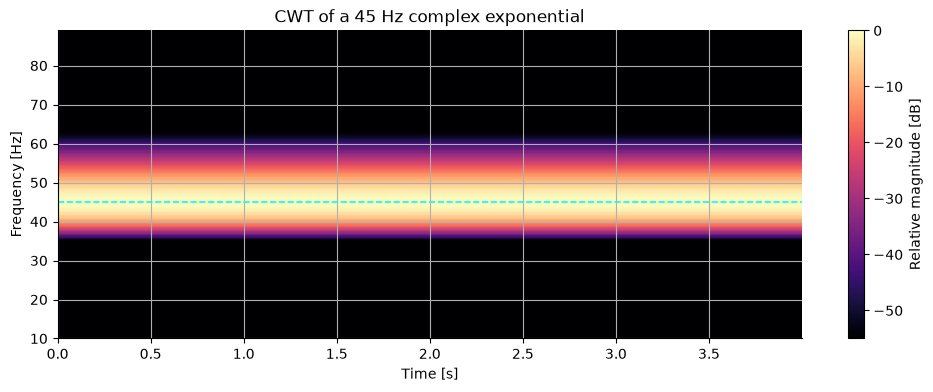

In [9]:
complex_signal = np.exp(1j * 2 * np.pi * 45.0 * t).astype(np.complex64)
complex_scales = fcwt2.Scales.linear_frequencies(sample_rate, 10.0, 90.0, 80)
transform = fcwt2.Fcwt.morlet(2.0)
complex_coeffs = transform.cwt_complex(complex_signal.tolist(), complex_scales)
complex_coeffs = np.asarray(complex_coeffs, dtype=np.complex64).reshape(
    len(complex_scales), complex_signal.size
)
complex_freqs = np.asarray(complex_scales.frequencies(), dtype=float)
order = np.argsort(complex_freqs)

fig, ax = plt.subplots(figsize=(12, 4))
image = plot_cwt(
    ax,
    t,
    complex_freqs[order],
    complex_coeffs[order],
    "CWT of a 45 Hz complex exponential",
    vmin_db=-55,
)
ax.axhline(45.0, color="cyan", lw=1.2, ls="--")
fig.colorbar(image, ax=ax, label="Relative magnitude [dB]")
plt.show()

## Practical checklist

- Keep `f1` at or below Nyquist: `sample_rate / 2`.
- Use more scales for smoother frequency detail; use fewer scales for speed.
- Start with `Scales.linear_frequencies(...)` when you want an easy-to-read frequency axis.
- Use `Scales.log(...)` when lower frequencies need more visual/detail emphasis.
- Reshape with `(len(scales), len(signal))`; `fcwt2` output is scale-major.